4/5 marker corners detected.
[[3]]


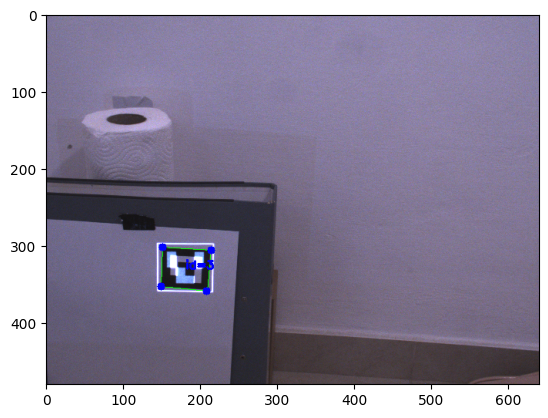

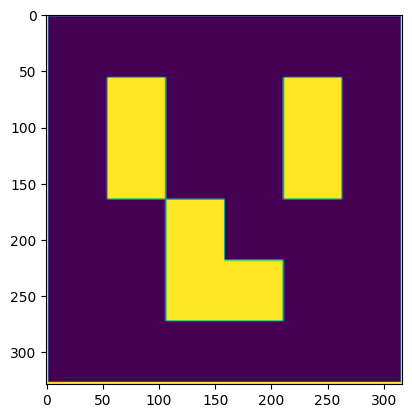

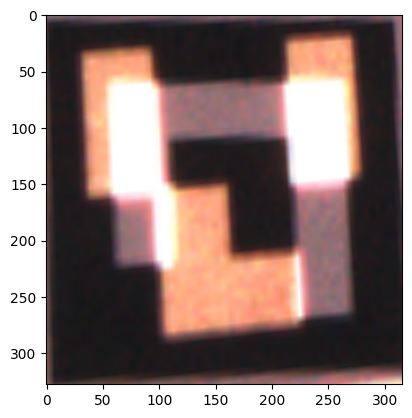

In [1]:
from capture_utils_v2 import CaptureSystem

# Initialize the capture system
system = CaptureSystem()

system.display_drawer()
system.run_aruco_detector()


In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [5]:
from tracking_utils import TrackerSystem

track_and_project() function defined!

Usage: track_and_project(system, your_image)
  - system: CaptureSystem object
  - your_image: numpy array of image to project
TrackerSystem class defined!

Usage:
  from classfier import *
  tracker = TrackerSystem(system, predict_raw, weights, printed_aruco_id=10)
  caps, results = tracker.track_project_and_classify(image_to_project)

Returns: (caps, results) - captured frames and classification results


In [13]:
from tracking_utils import TrackerSystem
self = TrackerSystem(predict_raw=None,weights=None, system=system)
cv2.destroyAllWindows()
cv2.namedWindow("Projection", cv2.WND_PROP_FULLSCREEN)
cv2.setWindowProperty("Projection", cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
cv2.imshow("Projection", system.img)
cv2.waitKey(1)


TrackerSystem initialized!


-1

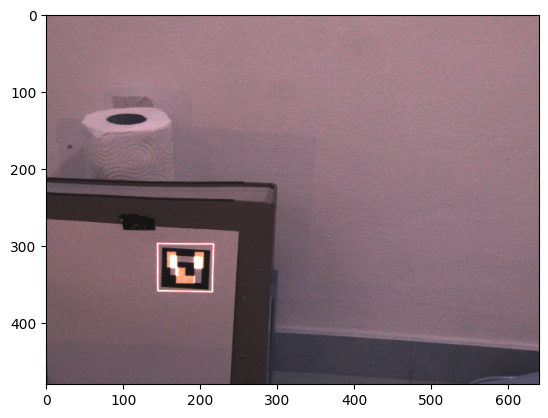

In [14]:
plt.imshow(system.cap.read()[1])

In [9]:
ret, frame = system.cap.read()

gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
corners, ids, _ = self.detector.detectMarkers(gray)

original_printed_corners = self.get_marker_corners(corners, ids, self.printed_aruco_id)



In [16]:
orig_img = system.img.copy()

In [17]:
original_printed_corners

array([[151., 303.],
       [212., 307.],
       [210., 357.],
       [150., 353.]], dtype=float32)

In [18]:
system.orig_proj_corners

array([[2070, 1562],
       [2386, 1562],
       [2386, 1890],
       [2070, 1890]])

In [19]:
system.corners_img_proj

array([[[151.     , 302.     ],
        [214.     , 306.     ],
        [208.87392, 359.04453],
        [149.     , 353.     ]]], dtype=float32)

In [20]:
import numpy as np
H_proj_2_cam = cv2.getPerspectiveTransform(np.array(system.orig_proj_corners, dtype=np.float32), np.array(system.corners_img_proj, dtype=np.float32))
print(H_proj_2_cam)

H_cam_to_proj2 = cv2.findHomography(np.array(system.orig_proj_corners, dtype=np.float32), np.array(system.corners_img_proj, dtype=np.float32),method=
                                   0)[0]
print(H_cam_to_proj2)

[[ 1.60238328e-01  1.50350550e-02 -2.12451527e+02]
 [-2.83661999e-02  1.96242839e-01  3.76398546e+01]
 [-1.31800234e-04  1.39587415e-04  1.00000000e+00]]
[[ 1.60238134e-01  1.50350323e-02 -2.12451201e+02]
 [-2.83662764e-02  1.96242660e-01  3.76400701e+01]
 [-1.31800453e-04  1.39587232e-04  1.00000000e+00]]


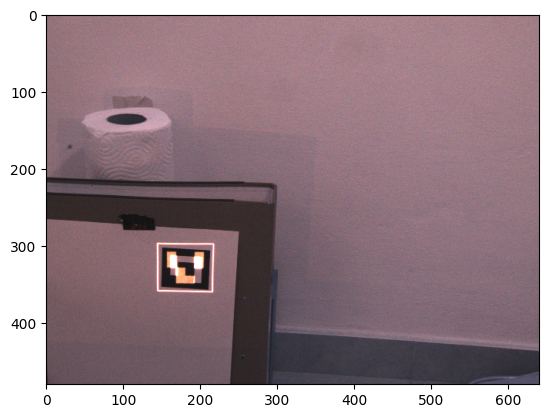

In [23]:
frame = system.cap.read()[1]
plt.imshow(frame)

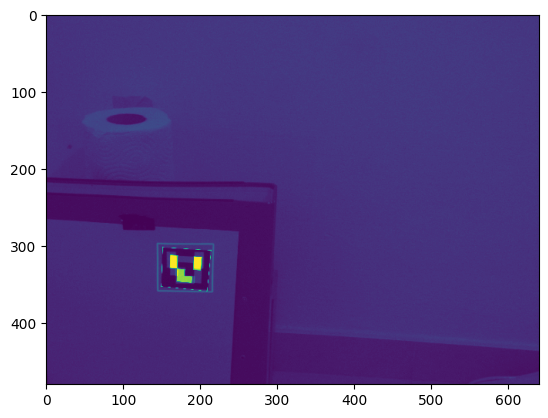

In [24]:
plt.imshow((frame[:,:,2]*0.5).astype(int) + cv2.warpPerspective(system.img, H_proj_2_cam, (frame.shape[1], frame.shape[0])))

In [25]:
# plt.imsshow(cv2.warpPerspective(system.img, H_proj_2_cam, (system.img.shape[1], system.img.shape[0])))

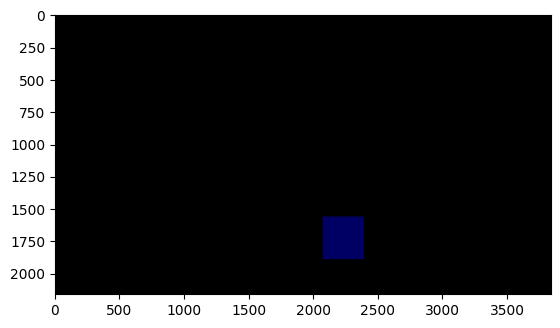

In [39]:
orig_img_corners = system.orig_proj_corners
# orig_image_white = np.zeros_like(orig_img)
# orig_image_white = cv2.fillPoly(orig_image_white, [np.array(orig_img_corners, dtype=np.int32)], (255,255,255))
# plt.imshow(orig_image_white)
orig_image_red = np.zeros((orig_img.shape[0], orig_img.shape[1], 3), dtype=np.uint8)
orig_image_red = cv2.fillPoly(orig_image_red, [np.array(orig_img_corners
, dtype=np.int32)], (0,0,100))
plt.imshow(orig_image_red)

In [ ]:
import numpy as np

# Reshape corners to (N, 1, 2) for perspectiveTransform
original_corners_reshaped = original_printed_corners.reshape(-1, 1, 2).astype(np.float32)

# Transform original marker corners from camera space to projector (cropped) space
original_proj_corners = cv2.perspectiveTransform(original_corners_reshaped, H_proj_2_cam)

# Work with the cropped projection region instead of full screen
orig_img_section = system.img_non_zero_section.copy()

for i in range(1000):
    ret, frame = self.system.cap.read()

    frame_display = frame.copy()

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    corners, ids, _ = self.detector.detectMarkers(gray)

    current_printed = self.get_marker_corners(corners, ids, self.printed_aruco_id)
    
    # Skip if marker not detected
    if current_printed is None:
        cv2.imshow('display', frame_display)
        cv2.waitKey(1)
        continue
        
    cv2.polylines(frame_display, [current_printed.astype(int)], True, (255, 0, 0), 2)
    cv2.imshow('display', frame_display)

    # COMPENSATION: Transform from CURRENT back to ORIGINAL (inverse direction)
    # This pre-warps the projection so it appears rectangular on the tilted surface
    # M = cv2.getPerspectiveTransform(current_printed.astype(np.float32), original_printed_corners.astype(np.float32))
    H_printed_cam_orig_to_current = cv2.getPerspectiveTransform(original_printed_corners,current_printed )
    # Convert camera-space transformation to projector-space
    M_proj = np.linalg.inv(H_proj_2_cam) @ H_printed_cam_orig_to_current @ H_proj_2_cam

    warped = cv2.warpPerspective(orig_image_red, M_proj, (orig_img.shape[1], orig_img.shape[0]))

    
    cv2.imshow('Projection', warped)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cv2.destroyWindow('display')

In [58]:
cv2.destroyWindow('display')

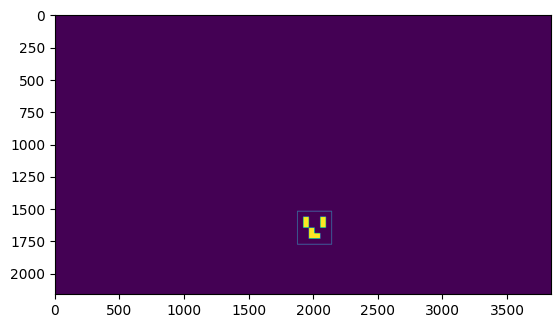

In [54]:
plt.imshow(orig_img)

In [ ]:
plt.imshow(frame)

In [ ]:
M_proj = np.linalg.inv(H_proj_2_cam) @ M @ H_proj_2_cam

warped = cv2.warpPerspective(orig_img, M_proj, (orig_img.shape[1], orig_img.shape[0]))

plt.imshow(warped)